In [1]:
import json 
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [19]:
# Load frame from json file
with open('frame_sample.json', 'r') as f:
    frame = json.load(f)
    frame = np.array(frame, dtype=np.uint8)
    frame = frame.reshape((210, 160, 3))

In [3]:
frame.shape

(210, 160, 3)

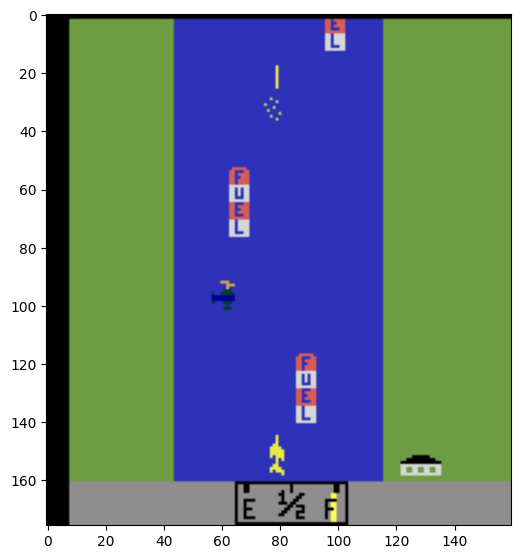

In [20]:
frame_modiffied = np.concat((frame[:161, :, :], frame[175:190, :, :]), axis=0)
# Visualize frame
plt.figure(figsize=(6, 8))
plt.imshow(frame_modiffied)
plt.show()

In [6]:
print("Raw frame shape:", frame_modiffied.shape)

Raw frame shape: (176, 160, 3)


In [3]:
torch.cuda.is_available()

False

In [3]:
keys = torch.rand(8, 3)
keys
    
        
    

tensor([[0.6446, 0.7121, 0.5954],
        [0.5297, 0.6368, 0.5658],
        [0.3759, 0.3083, 0.6180],
        [0.7194, 0.8252, 0.8892],
        [0.3956, 0.4089, 0.1538],
        [0.9490, 0.7445, 0.1319],
        [0.6391, 0.6596, 0.4004],
        [0.9797, 0.8448, 0.6601]])

In [17]:
key_0 = keys[0]
key_1 = keys[1]
key_2 = keys[2]
neighbor_keys = keys[3:]
neighbor_keys - key_0

tensor([[ 0.0747,  0.1131,  0.2937],
        [-0.2490, -0.3032, -0.4417],
        [ 0.3043,  0.0324, -0.4635],
        [-0.0056, -0.0525, -0.1950],
        [ 0.3350,  0.1327,  0.0647]])

In [ ]:
torch.norm(neighbor_keys - key_0, dim=1)

tensor([0.4856, 0.3235, 0.5908, 0.5554, 0.2020, 0.3661])

In [ ]:
similarities = torch.stack(
    [torch.norm(neighbor_keys - key_0, dim=1),
     torch.norm(neighbor_keys - key_1, dim=1),
     torch.norm(neighbor_keys - key_2, dim=1)]
)

tensor([[0.3235, 0.5908, 0.5554, 0.2020, 0.3661],
        [0.4196, 0.4896, 0.6128, 0.1995, 0.5046],
        [0.6772, 0.4754, 0.8689, 0.4899, 0.8088]])

In [15]:
from models.data_buffers import ReplayBucketType


remaining = 64-7 
bucket_rates ={
    ReplayBucketType.LOW: 0.15,
    ReplayBucketType.MEDIUM: 0.45,
    ReplayBucketType.HIGH: 0.3,
    ReplayBucketType.DEATH: 0.1,
}

bucket_take_counts = np.array(
    (round(remaining * bucket_rates[ReplayBucketType.DEATH]),
    round(remaining * bucket_rates[ReplayBucketType.HIGH]),
    round(remaining * bucket_rates[ReplayBucketType.LOW]),
    round(remaining * bucket_rates[ReplayBucketType.MEDIUM]),
    )
)

print(bucket_take_counts)
print(np.sum(bucket_take_counts))

[ 6 17  9 26]
58


# Frame Visualization

**!!** DO NOT REMOVE THIS PART.

In [4]:
from utils.plotting import plot_3d_array_grid

In [2]:
episode_frames_path = "episode_frames.json"

with open(episode_frames_path, "r") as f:
    data = json.load(f)

    # 2. Extract the list and convert it into a 3D NumPy array
    # Expected shape: (num_images, height, width)
    matrix_3d = np.array(data, dtype=np.uint8)

In [3]:
matrix_3d.shape

(236, 210, 160)

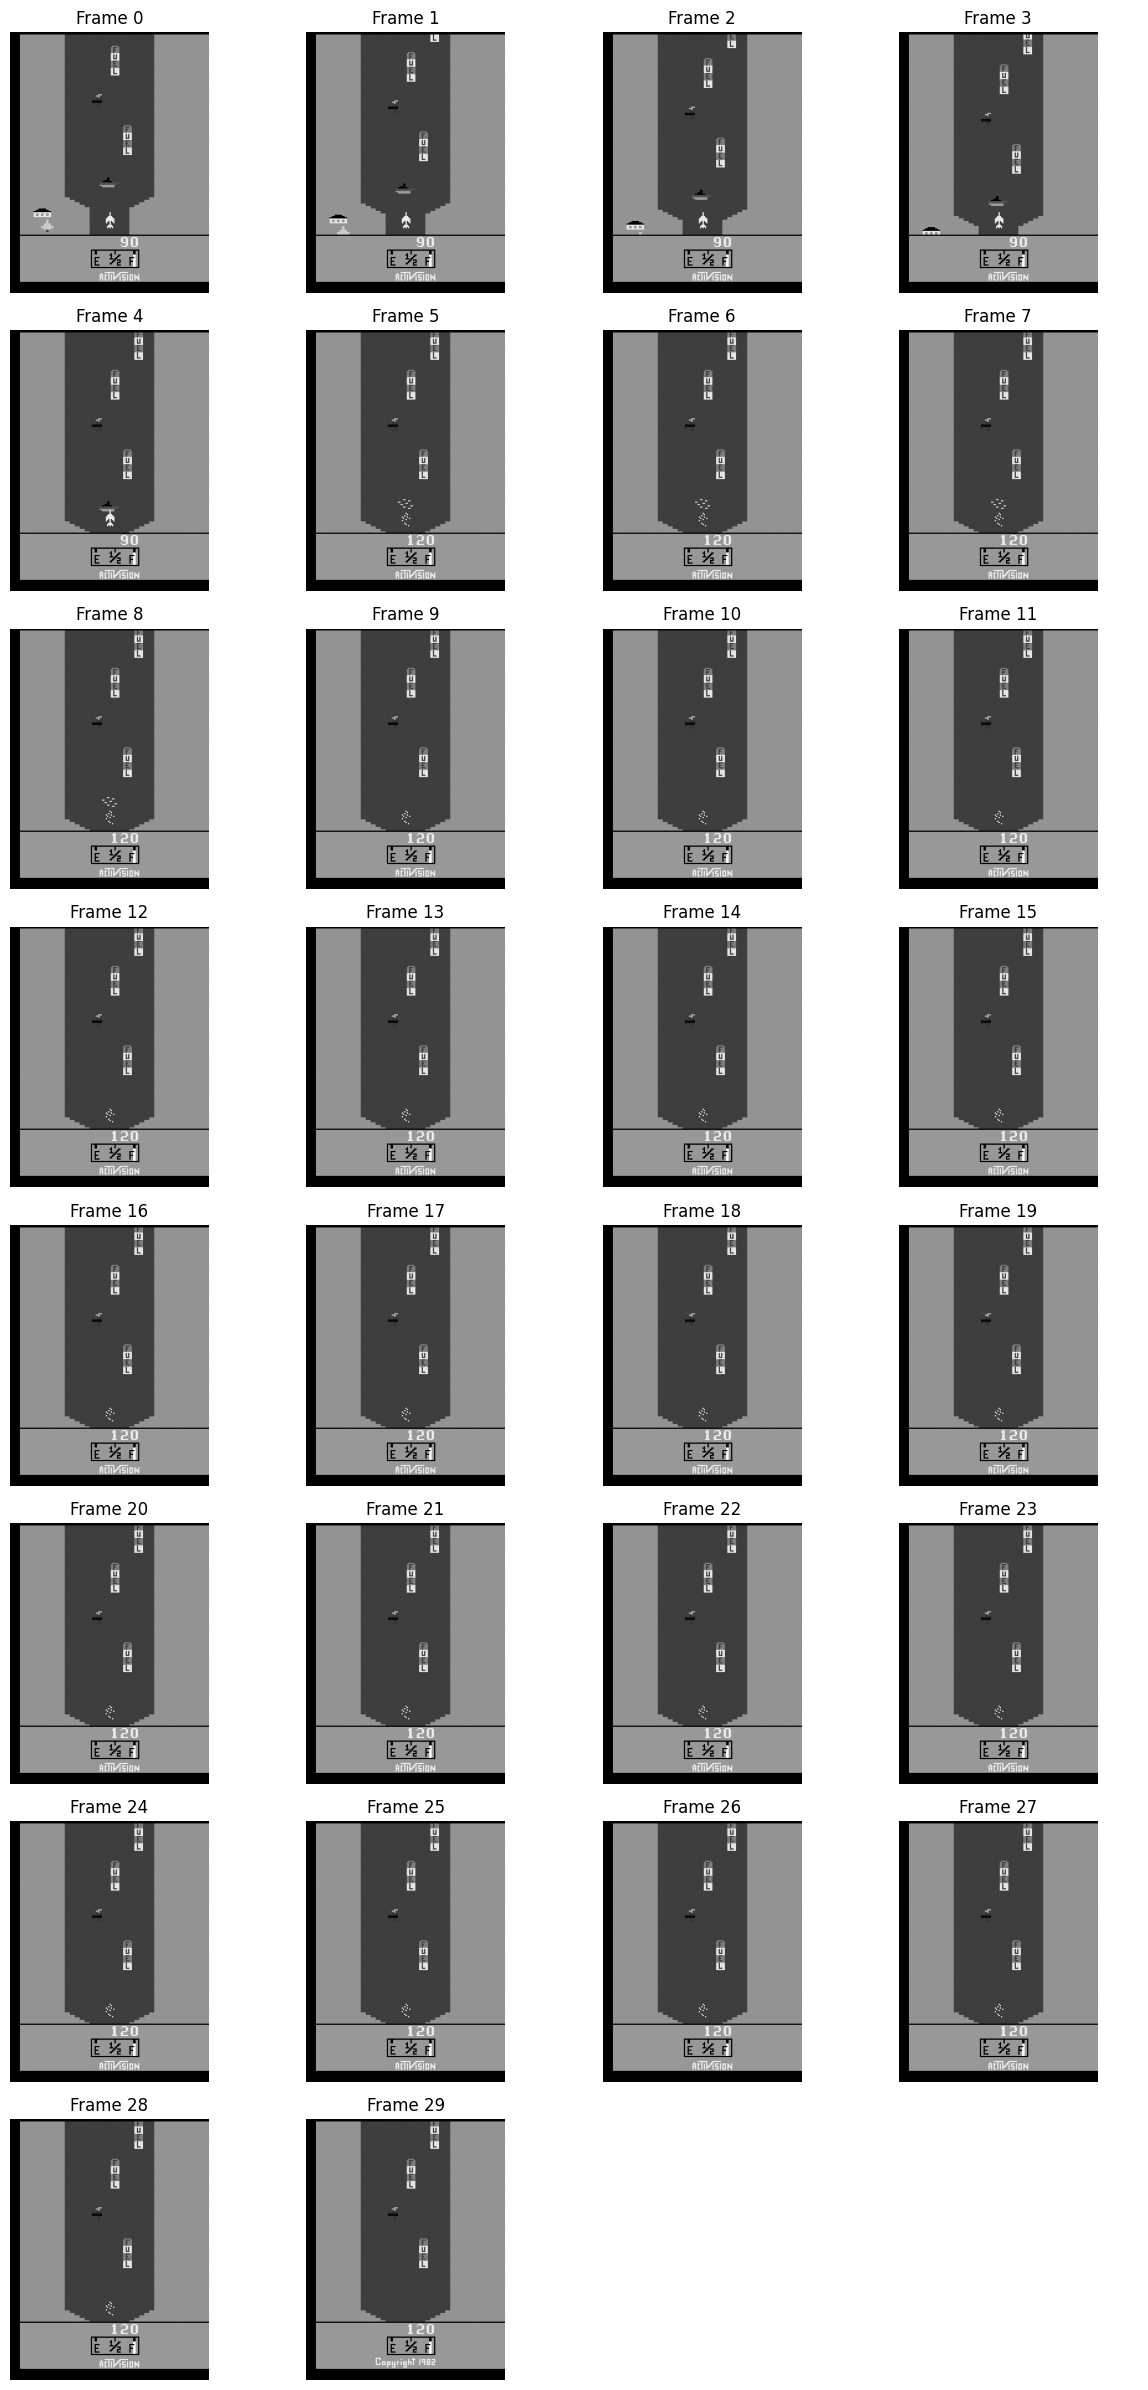

In [13]:
plot_3d_array_grid(matrix_3d[-30:], images_per_row=4, cmap="gray", title_prefix="Frame")

**Static Frame Counts to Remove Them**

Static frames are basically non-interactable frames. In other words action has no consequence and an uncrashed plane is not in the frame.

* *Initial Static Frames: 22*
* *Intermediate Static Frames: 45*
* *Terminal Static Frames: 25*

In [1]:
22+45*3+25

182